## 角度

回顾上一节关于距离和速度的仿真代码

Beat frequency: 5.34 MHz
Phase delta: 1.27 radians
Maximum velocity: 24.65 m/s
Velocity resolution: 0.77 m/s


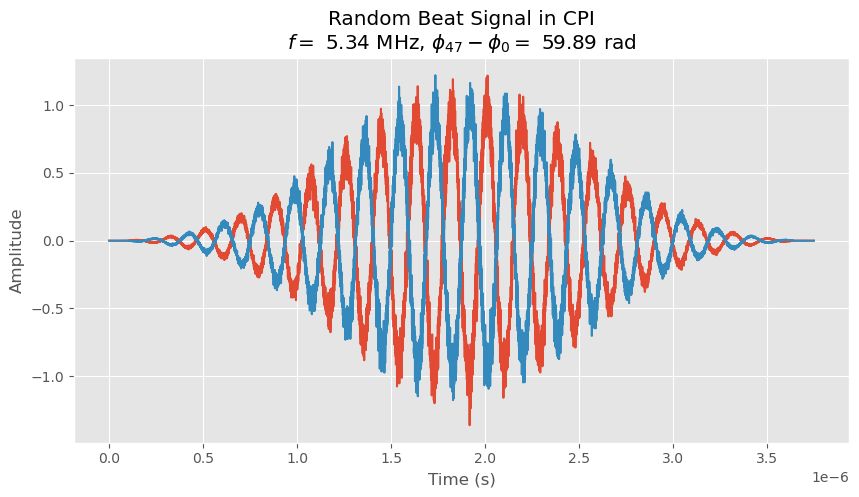

In [1]:
import numpy as np
from random import randint
import matplotlib.pyplot as plt
from scipy import signal
from scipy.constants import c, pi, mph
from numpy.fft import fft, fftshift, fft2
from matplotlib import cm

%matplotlib inline
plt.style.use("ggplot")


def compute_phase_diff(v):
    # 计算因目标径向速度 v 引起的相位差
    # 时间延迟 Δτ = 2·v·Tc / c
    time_from_vel = 2 * (v * Tc) / c  
    # 相位差 Δφ = 2π·f·Δτ
    return 2 * pi * f * time_from_vel  

def compute_f_beat(R):
    # 计算距离 R 对应的拍频
    # f_beat = 2·R·B / (c·Tc)
    return (2 * R * bw) / (c * Tc)  

# Radar setup
f = 76e9  # Hz
Tc = 40e-6  # chirp time - s
bw = 1.6e9  # bandwidth - Hz
chirp_rate = bw / Tc  # Hz/s


wavelength = c / f
M = 64  # number of chirps in coherent processing interval (CPI)

# Target
R = 20  # m
v = 10  # m/s

# 计算并打印拍频和相位差
f_beat = compute_f_beat(R)         # 拍频，单位 Hz
phase_diff = compute_phase_diff(v) # 速度引起的相位差，单位 rad

print(f"Beat frequency: {f_beat/1e6:.2f} MHz")  
print(f"Phase delta: {phase_diff:.2f} radians")  

# 计算多普勒速度测量能力
# 无歧义最大速度 v_max = λ / (4·Tc)
max_vel = wavelength / (4 * Tc)  
# 速度分辨率 Δv = λ / (2·M·Tc)
vel_res = wavelength / (2 * M * Tc)  

print(f"Maximum velocity: {max_vel:.2f} m/s")      
print(f"Velocity resolution: {vel_res:.2f} m/s")   

max_time = 20 / f_beat # s
N = 10000
Ts = max_time / N # s
fs = 1 / Ts # Hz
t = np.arange(0, max_time, 1 / fs)

window = signal.windows.blackman(N)  # 生成 Blackman 窗，长度为 N，用于抑制频谱泄漏

# 构造 M 个 Chirp 的基带信号并加窗，加上高斯噪声以模拟实际信号
cpi_single = np.array([
    (
        np.sin(2 * pi * compute_f_beat(R) * t + m * phase_diff)  # 正弦基带信号，频率由距离 R 决定，并叠加第 m 次的相位偏移
        + np.random.normal(0, 0.1, N)  # 添加均值 0、标准差 0.1 的白噪声
    ) * window  # 对信号进行加窗操作
    for m in range(M)  # 对 M 次 Chirp 重复上述过程
])

n = randint(0, M - 1)  # 随机选取一个 Chirp 的索引，用于后续绘图展示

plt.figure(figsize=(10, 5))  
plt.plot(t, cpi_single[n])    # 绘制第 n 个 Chirp 的时域信号
plt.plot(t, cpi_single[0])    # 绘制第 0 个 Chirp 的时域信号，便于比较
plt.title(
    f"Random Beat Signal in CPI\n"
    f"$f=\\ ${f_beat/1e6:.2f} MHz, $\\phi_{{{n}}} - \\phi_0 =\\ ${n*phase_diff:.2f} rad"
)  # 设置标题，显示 Beat 频率和相位差信息
plt.xlabel("Time (s)")      
plt.ylabel("Amplitude")     
plt.show()                 

设置天线数量以及入射角度

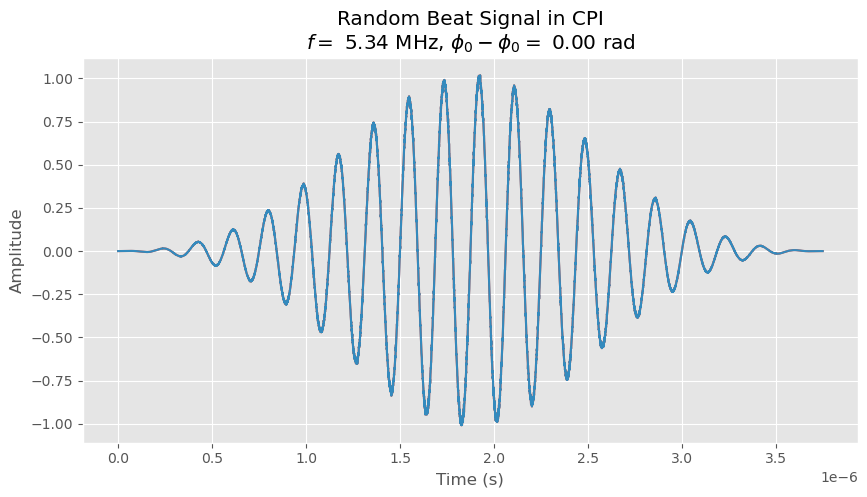

In [2]:
# 多天线参数  
N_rx    = 2                 # 接收天线数  
d       = wavelength / 2    # 天线间距，通常取 λ/2  
theta   = np.deg2rad(14.8)    # 目标入射角（示例 30°）  

# 计算每个天线的固定阵列相位偏移 φ_rx[i]  
# φ_rx[i] = 2π·(i·d·sinθ) / λ  
rx_indices = np.arange(N_rx)  
phase_rx = 2 * np.pi * (rx_indices * d * np.sin(theta)) / wavelength  
# print(phase_rx)

f_beat    = compute_f_beat(R)  
phase_diff = compute_phase_diff(v)  

# 初始化多天线、多 Chirp 的基带信号数组  
# 形状： (N_rx, M, N)  
cpi_array = np.zeros((N_rx, M, N))  

for rx in range(N_rx):  
    for m in range(M):  
        # 基带正弦信号 + 噪声  
        sig = np.sin(2 * np.pi * f_beat * t + m * phase_diff + phase_rx[rx])  
        sig += np.random.normal(0, 0.01, N)  
        # 加窗  
        cpi_array[rx, m, :] = sig * window


n = randint(0, M - 1)  # 随机选取一个 Chirp 的索引，用于后续绘图展示

plt.figure(figsize=(10, 5))  
plt.plot(t, np.squeeze(cpi_array[0,n,:]))    # 绘制第 n 个 Chirp 的时域信号
plt.plot(t, np.squeeze(cpi_array[0,0,:]))    # 绘制第 0 个 Chirp 的时域信号，便于比较
plt.title(
    f"Random Beat Signal in CPI\n"
    f"$f=\\ ${f_beat/1e6:.2f} MHz, $\\phi_{{{n}}} - \\phi_0 =\\ ${n*phase_diff:.2f} rad"
)  # 设置标题，显示 Beat 频率和相位差信息
plt.xlabel("Time (s)")      
plt.ylabel("Amplitude")     
plt.show()  

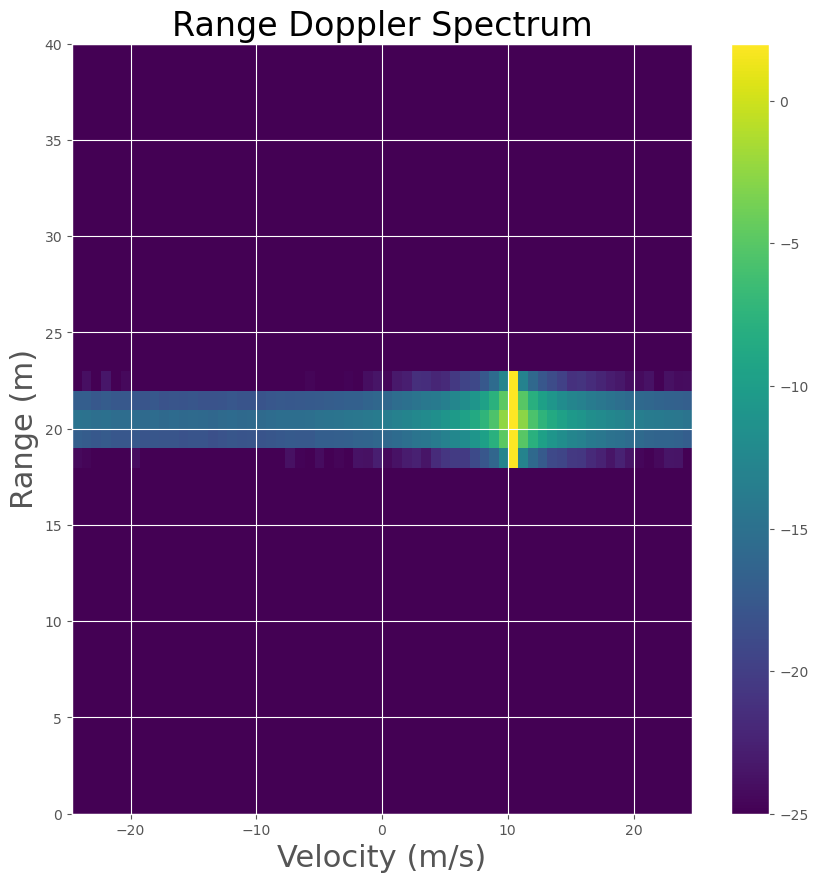

In [3]:
# 生成速度轴，范围从 -max_vel 到 max_vel，共 M 个点
vels = np.linspace(-max_vel, max_vel, M)

radarCube = np.zeros((N_rx, N, M), dtype=np.complex64)  
for i in range(N_rx):
    cpi_single = np.squeeze(cpi_array[i,:,:])
    # 计算距离-多普勒二维谱：
    # 对加窗并叠加噪声的 CPI 信号矩阵做二维 FFT
    # cpi_single 的形状为 (M, N)，转置后每列为一个 Chirp
    # fft2 返回 M×N 的频谱矩阵，fftshift 将零频移到中心
    # 然后取幅值并归一化
    range_doppler = fftshift((fft2(cpi_single.T))) / (N / 2)
    radarCube[i,:,:] = range_doppler

rmax = c * Tc * fs / (2 * bw)  # 最大可测距离 Rmax = c·Tc·fs/(2·bw)
n_ranges = np.linspace(-rmax / 2, rmax / 2, N)    
ranges   = np.linspace(-rmax / 2, rmax / 2, N)  

extent = [-max_vel, max_vel, ranges.min(), ranges.max()]

# 绘制RDMAP
fig, ax = plt.subplots(figsize=(10, 10))  
range_doppler_plot = ax.imshow(
    10 * np.log10(np.abs(radarCube[0,:,:])),  
    aspect="auto",                 
    extent=extent,                 
    origin="lower",                
    vmax=2,                        
    vmin=-25,                       
)

ax.set_ylim([0, 40])  
ax.set_title("Range Doppler Spectrum", fontsize=24) 
ax.set_xlabel("Velocity (m/s)", fontsize=22)         
ax.set_ylabel("Range (m)", fontsize=22)             
# ax.set_ylabel("Frequency (MHz)", fontsize=22)      

fig.colorbar(range_doppler_plot) 
plt.show()     

潜在目标提取，获取距离单元和速度单元索引

In [4]:
# # 4. CFAR 目标检测（以第 0 根天线为例做简单 1D CA-CFAR，沿距离轴）  
# Tr = 10      # 训练单元数
# Gr = 2       # 保护单元数
# Pfa = 1e-6   # 期望虚警率
# N_train = 2 * Tr
# alpha = N_train * (Pfa ** (-1 / N_train) - 1)  # 阈值缩放因子

# detections = []  # 存储检测到的目标 (range_idx, doppler_idx)
# sub_radarCube = np.squeeze(np.abs(radarCube[0,:,:]))
# for d_idx in range(M):
#     for r_idx in range(Tr + Gr, fft_len - (Tr + Gr)):
#         # 训练单元：CUT 左右各 Tr 单元，跳过 Gr 个保护单元
#         left_noise  = np.sum(sub_radarCube[d_idx, r_idx - Gr - Tr : r_idx - Gr])
#         right_noise = np.sum(sub_radarCube[d_idx, r_idx + Gr + 1 : r_idx + Gr + Tr + 1])
#         noise_level = (left_noise + right_noise) / N_train
#         threshold = noise_level + 10 * np.log10(alpha)
#         if sub_radarCube[d_idx, r_idx] > threshold:
#             print(r_idx,d_idx)
#             detections.append((r_idx, d_idx))


# 简化，提取max
sub_radarCube = np.squeeze(np.abs(radarCube[0,:,:]))
print(sub_radarCube.shape)
max_val = sub_radarCube[int(N/2):-1,:].max()
# 返回所有等于最大值的索引数组
r_idx, d_idx = np.where(sub_radarCube[int(N/2):-1,:] == max_val)

print("最大值：", max_val)   
print("所有位置：", list(zip(r_idx, d_idx)))
print(n_ranges[int(N/2) + r_idx[0]])

(10000, 64)
最大值： 26.85876
所有位置： [(20, 45)]
20.50205020502017


## 方法一：直接使用FFT进行角度估计

[-1.689246-26.805588j 18.102968-19.84179j ]


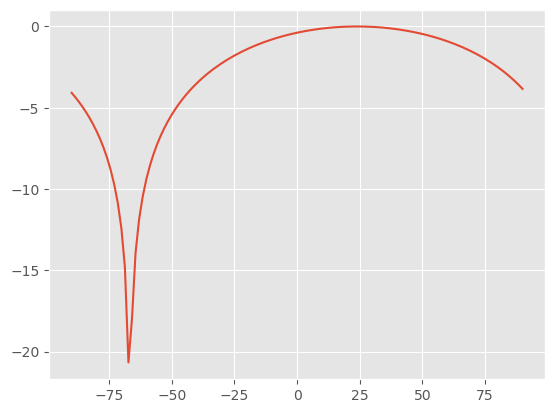

(501.29047-518.7784j)
(0.7682512467667983-6.12961620301653j)


In [15]:
# 5. 基于角度 FFT 的角度估计
#    对每个检测到的 (range_idx, doppler_idx)，抽取 N_rx 天线的复数响应，做角度 FFT
n_angle = 128
angles = np.linspace(-90, 90, n_angle)  # 角度搜索网格
angle_estimates = []

snapshot = radarCube[:, int(N/2) + r_idx[0], d_idx[0]] 
print(snapshot)
ang_spec = np.abs(fftshift(fft(snapshot, n=n_angle)))
plt.plot(angles, 10*np.log10(ang_spec/ang_spec.max()))
plt.show()

## 方法二：基于相位差进行角度估计（两天线情况下）

In [32]:
Rx1, Rx2 = snapshot[0], snapshot[1]
phase1, phase2 = np.arctan2(np.imag(Rx1), np.real(Rx1)), np.arctan2(np.imag(Rx2), np.real(Rx2))
diff_phase = phase2 - phase1
print(f'相位差：{diff_phase:.4f} rad')

d_idx = wavelength / 2
theta = np.arcsin(wavelength/(2*np.pi*d_idx)*diff_phase) / np.pi* 180
print(f'角度：{theta:.4f}')

相位差：0.8025 rad
角度：14.8006


## 其他方法：使用CAPON以及MUSIC进行角度估计

[14.800636]


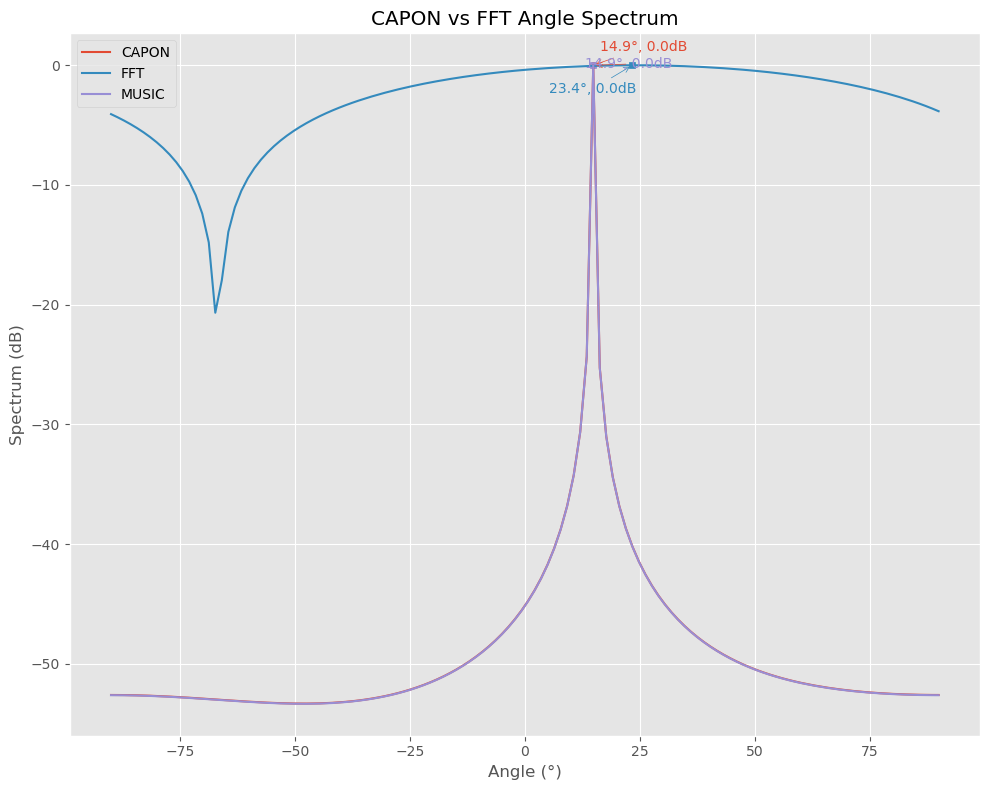

In [40]:
def doa_fft(received_signals, fft_num):
    search_angles = np.linspace(-90, 90, fft_num)
    fft_data = np.abs(np.fft.fftshift(np.fft.fft(received_signals, fft_num)))
    fft_spectrum = 10 * np.log10(fft_data / np.max(fft_data))
    
    return search_angles, fft_spectrum


def doa_capon(received_signals, spacing=0.5, n=90):
    """
    Capon (MVDR) beamforming for a uniform linear array (ULA)

    :param numpy.2darray covmat:
        Sensor covariance matrix, specified as a complex-valued, positive-
        definite M-by-M matrix. The quantity M is the number of elements
        in the ULA array
    :param float spacing:
        Distance (wavelength) between array elements. ``default 0.5``
    :param numpy.1darray scanangles:
        Broadside search angles, specified as a real-valued vector in degrees.
        Angles must lie in the range [-90°,90°] and must be in increasing
        order. ``default [-90°,90°] ``

    :return: spectrum in dB
    :rtype: numpy.1darray
    """
    # 计算协方差矩阵
    R = received_signals @ received_signals.conj().T
    R /= np.trace(R)
    
    n_covmat = np.shape(R)[0]
    array = np.linspace(0, (n_covmat - 1) * spacing, n_covmat)
    scanangles = np.linspace(-90, 90, n)

    array_grid, angle_grid = np.meshgrid(array, np.radians(scanangles), indexing="ij")
    steering_vect = np.exp(1j * 2 * np.pi * array_grid * np.sin(angle_grid)) / np.sqrt(n_covmat)

    R = R + np.eye(n_covmat) * 0.000000001
    inv_covmat = np.linalg.pinv(R)

    ps = np.zeros(scanangles.shape)
    for idx, _ in enumerate(scanangles):
        s_vect = steering_vect[:, idx]

        weight = inv_covmat @ s_vect / (s_vect.T.conj() @ inv_covmat @ s_vect)
        ps[idx] = np.abs(weight.T.conj() @ R @ weight)

    ps = 10 * np.log10(ps / ps.max())
    return scanangles, ps


# using MUSIC
def doa_music(received_signals, num_sources, num_antennas, n):
    """ MUSIC算法实现 """
    # 计算协方差矩阵
    R = received_signals @ received_signals.conj().T
    R /= np.trace(R)
    
    # 特征值分解
    eigenvalues, eigenvectors = np.linalg.eigh(R)
    idx = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    # 噪声子空间
    noise_subspace = eigenvectors[:, num_sources:]
    
    # 搜索角度
    search_angles = np.linspace(-90, 90, n)
    search_rad = np.deg2rad(search_angles)
    music_spectrum = np.zeros(search_angles.shape)
    
    for i, angle in enumerate(search_rad):
        steering_vector = np.exp(2j * np.pi * 0.5 * np.arange(num_antennas) * np.sin(angle))
        music_spectrum[i] = 1 / np.abs(steering_vector.conj().T @ noise_subspace @ noise_subspace.conj().T @ steering_vector)
    
    music_spectrum = 10 * np.log10(music_spectrum/music_spectrum.max())  # 转换为dB
    return search_angles, music_spectrum


def doa_esprit(received_signals, num_sources, spacing: float = 0.5):
    """
    Estimate arrival directions of signals using ESPRIT for a uniform linear
    array (ULA)

    :param numpy.2darray covmat:
        Sensor covariance matrix, specified as a complex-valued, positive-
        definite M-by-M matrix. The quantity M is the number of elements
        in the ULA array
    :param int nsig:
        Number of arriving signals, specified as a positive integer. The
        number of signals must be smaller than the number of elements in
        the ULA array
    :param float spacing:
        Distance (wavelength) between array elements. ``default 0.5``

    :return: doa angles in degrees
    :rtype: list
    """

    covmat = received_signals @ received_signals.conj().T
    _, eig_vects = np.linalg.eigh(covmat)
    signal_subspace = eig_vects[:, -num_sources:]

    # the original array is divided into two subarrays
    # [0,1,...,N-2] and [1,2,...,N-1]
    phi = np.linalg.pinv(signal_subspace[0:-1]) @ signal_subspace[1:]
    eigs = np.linalg.eigvals(phi)
    return np.degrees(np.arcsin(np.angle(eigs) / np.pi / (spacing / 0.5)))




# 获取所有RX通道数据
snapshot2 = np.expand_dims(snapshot,1)

# 分别采用不同的算法解算角度信息
angles_capon, capon_spectrum = doa_capon(snapshot2, n=n_angle)
angles_fft, fft_spectrum = doa_fft(snapshot2[:,0], fft_num=n_angle)
angles_music, music_spectrum = doa_music(snapshot2, 1, N_rx, n_angle)
angles_esprit = doa_esprit(snapshot2, 1, 0.5)
print(angles_esprit)

# 找到两条曲线的最大值及其索引
idx_capon = np.argmax(capon_spectrum)
x_capon  = angles_capon[idx_capon]
y_capon  = capon_spectrum[idx_capon]

idx_fft   = np.argmax(fft_spectrum)
x_fft    = angles_fft[idx_fft]
y_fft    = fft_spectrum[idx_fft]

idx_music   = np.argmax(music_spectrum)
x_music    = angles_music[idx_music]
y_music    = music_spectrum[idx_music]

# 画图
plt.figure(figsize=(10,8))
plt.plot(angles_capon, capon_spectrum, label='CAPON')
plt.plot(angles_fft,        fft_spectrum,   label='FFT')
plt.plot(angles_music,        music_spectrum,   label='MUSIC')

# 在最大值处画标记
plt.scatter([x_capon], [y_capon], color='C0', marker='o', s=20, label='_nolegend_')
plt.scatter([x_fft],    [y_fft],    color='C1', marker='s', s=20, label='_nolegend_')
plt.scatter([x_music],    [y_music],    color='C2', marker='s', s=20, label='_nolegend_')


# 添加文字注释
plt.annotate(
    f"{x_capon:.1f}°, {y_capon:.1f}dB",
    xy=(x_capon, y_capon),
    xytext=(5, 10),
    textcoords='offset points',
    color='C0',
    arrowprops=dict(arrowstyle='->', color='C0')
)
plt.annotate(
    f"{x_fft:.1f}°, {y_fft:.1f}dB",
    xy=(x_fft, y_fft),
    xytext=(-60, -20),
    textcoords='offset points',
    color='C1',
    arrowprops=dict(arrowstyle='->', color='C1')
)

plt.annotate(
    f"{x_music:.1f}°, {y_music:.1f}dB",
    xy=(x_music, y_music),
    xytext=(-6, -2),
    textcoords='offset points',
    color='C2',
    arrowprops=dict(arrowstyle='->', color='C21')
)

plt.xlabel("Angle (°)")
plt.ylabel("Spectrum (dB)")
plt.title("CAPON vs FFT Angle Spectrum")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 引申阅读：
1. [DOA估计算法——Capon算法](https://blog.csdn.net/Poulen/article/details/134462735)
2. [精选论文 | Capon算法与MUSIC算法性能的比较与分析](https://blog.csdn.net/qq_35844208/article/details/129043319)
3. [DOA估计算法——ESPRIT算法](https://blog.csdn.net/Poulen/article/details/144487037)